In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

LETTER_DATASET_PATH = "/kaggle/input/datasets/muhammadalbrham/rgb-arabic-alphabets-sign-language-dataset/RGB ArSL dataset"
NUMBERS_DATASET_PATH = "/kaggle/input/datasets/mariamabdelfattah76/egsl-for-numbers-sign-language/numbers_dataset_jpg"

# Dataset Overview

In [2]:
def dataset_overview(dataset_path):
    classes = sorted(os.listdir(dataset_path))
    num_classes = len(classes)

    total_images = 0
    class_counts = {}

    for cls in classes:
        cls_path = os.path.join(dataset_path, cls)
        if not os.path.isdir(cls_path):
            continue

        images = os.listdir(cls_path)
        count = len(images)

        class_counts[cls] = count
        total_images += count

    print(f"Number of classes: {num_classes}")
    print(f"Total images: {total_images}")

    return class_counts

# Class Distribution

In [3]:
def plot_class_distribution(class_counts):
    df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])
    df = df.sort_values(by="Count", ascending=False)

    plt.figure(figsize=(12, 5))
    plt.bar(df["Class"], df["Count"])
    plt.xticks(rotation=90)
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.show()

    return df

# Sample Visualization (Improved Version)

In [4]:
def show_sample_images(dataset_path, samples_per_class=3, num_classes=4):
    classes = sorted(os.listdir(dataset_path))[:num_classes]

    for cls in classes:
        cls_path = os.path.join(dataset_path, cls)
        images = os.listdir(cls_path)[:samples_per_class]

        plt.figure(figsize=(samples_per_class * 3, 3))

        for i, img_name in enumerate(images):
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(1, samples_per_class, i + 1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(cls)

        plt.suptitle(f"Class: {cls}")
        plt.tight_layout()
        plt.show()

# Image Properties Analysis

In [5]:
def analyze_image_properties(dataset_path, sample_size=500):
    widths, heights, channels = [], [], []

    all_images = []

    for cls in os.listdir(dataset_path):
        cls_path = os.path.join(dataset_path, cls)
        if not os.path.isdir(cls_path):
            continue

        for img_name in os.listdir(cls_path):
            all_images.append(os.path.join(cls_path, img_name))

    sample_images = all_images[:sample_size]

    for img_path in tqdm(sample_images):
        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w, c = img.shape
        heights.append(h)
        widths.append(w)
        channels.append(c)

    print("Height range:", min(heights), "-", max(heights))
    print("Width range:", min(widths), "-", max(widths))
    print("Channels:", set(channels))

# Data Quality Checks

In [6]:
def check_data_quality(dataset_path):
    corrupted = []
    total = 0

    for cls in os.listdir(dataset_path):
        cls_path = os.path.join(dataset_path, cls)

        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            total += 1

            img = cv2.imread(img_path)
            if img is None:
                corrupted.append(img_path)

    print(f"Total images checked: {total}")
    print(f"Corrupted images: {len(corrupted)}")

    return corrupted

# Label Inspection

In [7]:
def inspect_labels(dataset_path):
    classes = os.listdir(dataset_path)

    cleaned = sorted([cls.strip().lower() for cls in classes])

    print("Original Labels:")
    print(classes[:10])

    print("\nCleaned Labels:")
    print(cleaned[:10])

    duplicates = [item for item, count in Counter(cleaned).items() if count > 1]

    if duplicates:
        print("\n⚠️ Duplicate labels found:", duplicates)
    else:
        print("\n✅ No duplicate labels")

# Latter EDA

In [8]:
class_counts = dataset_overview(LETTER_DATASET_PATH)

Number of classes: 31
Total images: 7856


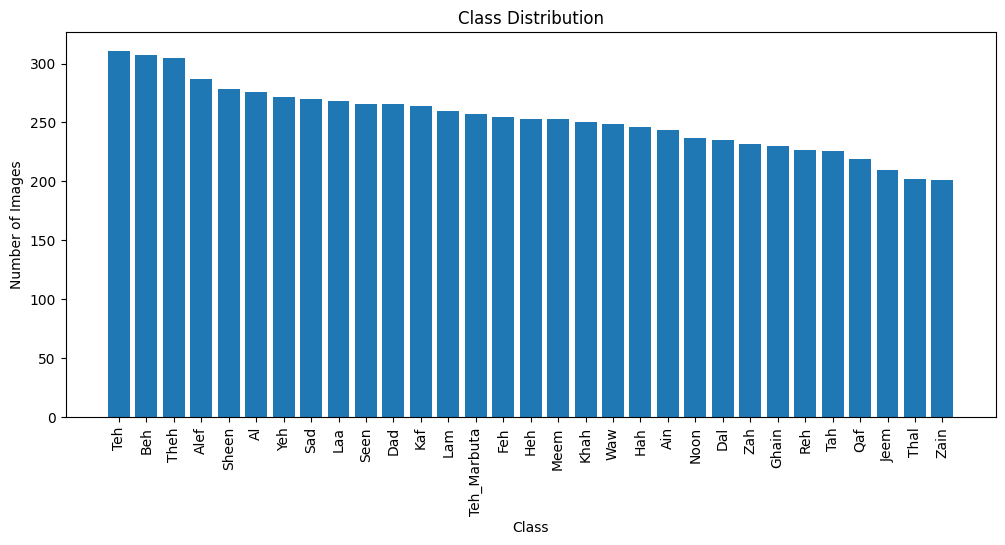

In [9]:
df = plot_class_distribution(class_counts)

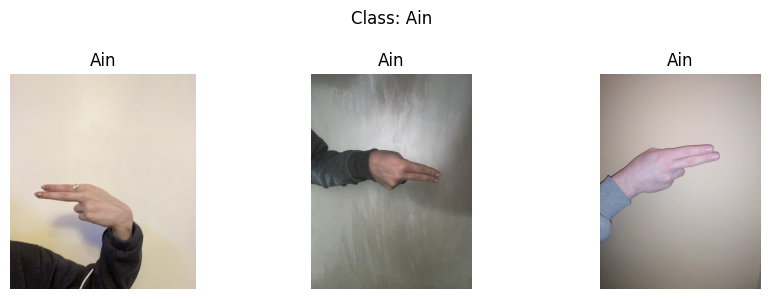

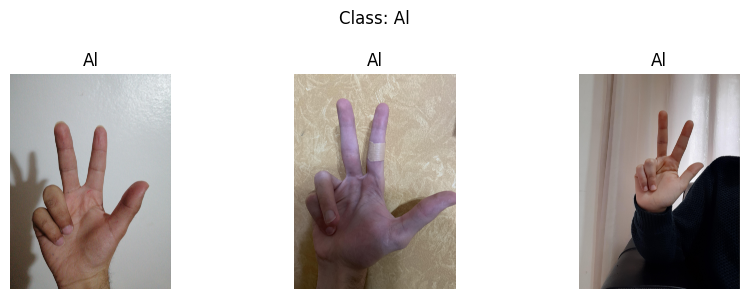

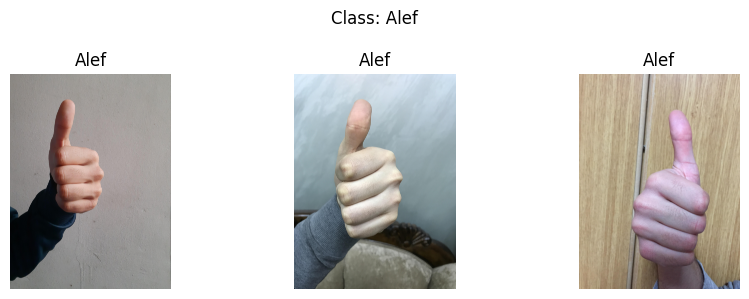

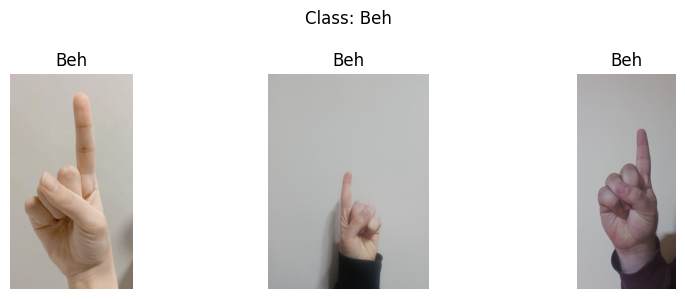

In [10]:
show_sample_images(LETTER_DATASET_PATH)

In [11]:
analyze_image_properties(LETTER_DATASET_PATH)

100%|██████████| 500/500 [00:36<00:00, 13.80it/s]

Height range: 200 - 6528
Width range: 200 - 4896
Channels: {3}


In [12]:
corrupted = check_data_quality(LETTER_DATASET_PATH)

Total images checked: 7856
Corrupted images: 0


In [13]:
inspect_labels(LETTER_DATASET_PATH)

Original Labels:
['Zain', 'Zah', 'Meem', 'Seen', 'Teh', 'Lam', 'Dad', 'Teh_Marbuta', 'Reh', 'Sad']

Cleaned Labels:
['ain', 'al', 'alef', 'beh', 'dad', 'dal', 'feh', 'ghain', 'hah', 'heh']

✅ No duplicate labels


# Numbers EDA

In [14]:
class_counts = dataset_overview(NUMBERS_DATASET_PATH)

Number of classes: 11
Total images: 581


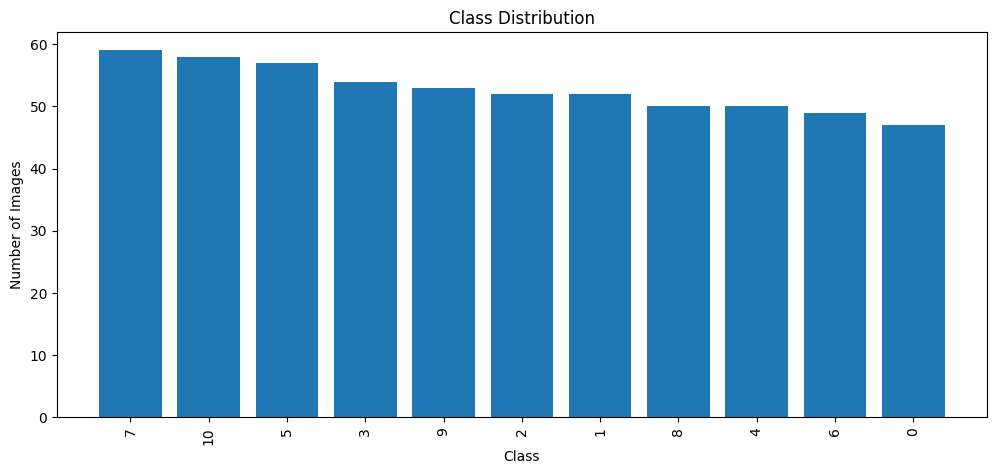

In [15]:
df = plot_class_distribution(class_counts)

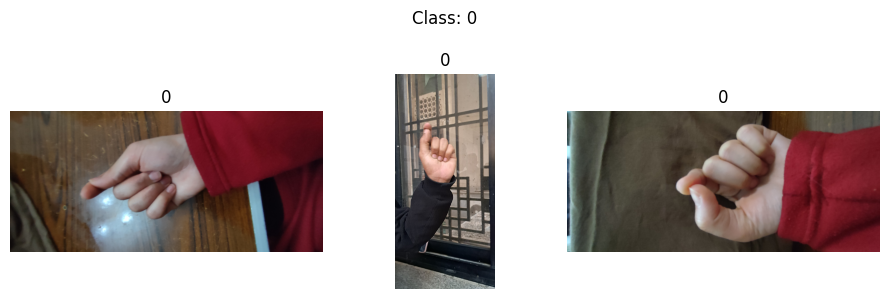

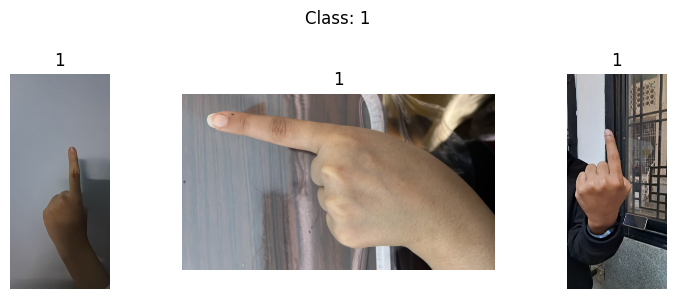

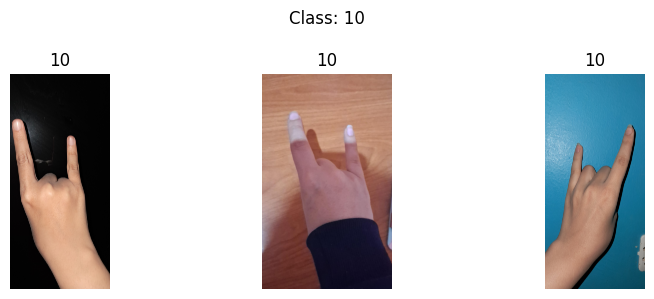

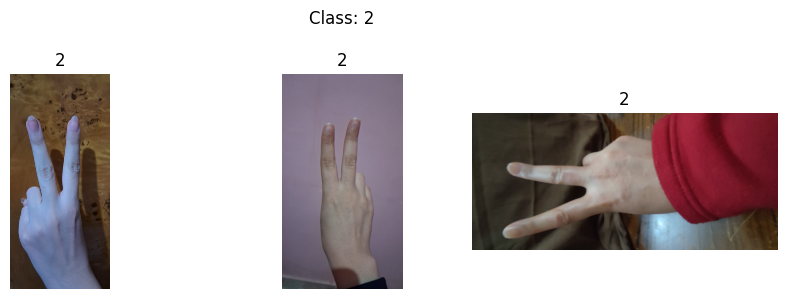

In [16]:
show_sample_images(NUMBERS_DATASET_PATH)

In [17]:
analyze_image_properties(NUMBERS_DATASET_PATH)

100%|██████████| 500/500 [00:28<00:00, 17.28it/s]

Height range: 428 - 4080
Width range: 626 - 4080
Channels: {3}


In [18]:
corrupted = check_data_quality(NUMBERS_DATASET_PATH)

Total images checked: 581
Corrupted images: 0


In [19]:
inspect_labels(NUMBERS_DATASET_PATH)

Original Labels:
['7', '2', '10', '5', '8', '0', '3', '1', '4', '9']

Cleaned Labels:
['0', '1', '10', '2', '3', '4', '5', '6', '7', '8']

✅ No duplicate labels
